Epoch 1/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 121s 50ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 2/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 110s 50ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 3/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 4/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 109s 50ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 5/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 6/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 7/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 102s 47ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 8/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 9/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 10/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 11/40
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - loss: 9.9634e-04 - val_loss: 

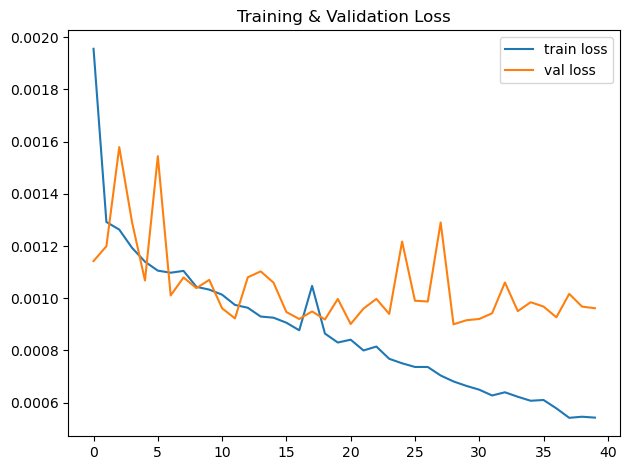

274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
MAE: 7.764, RMSE: 17.401, R²: 0.696


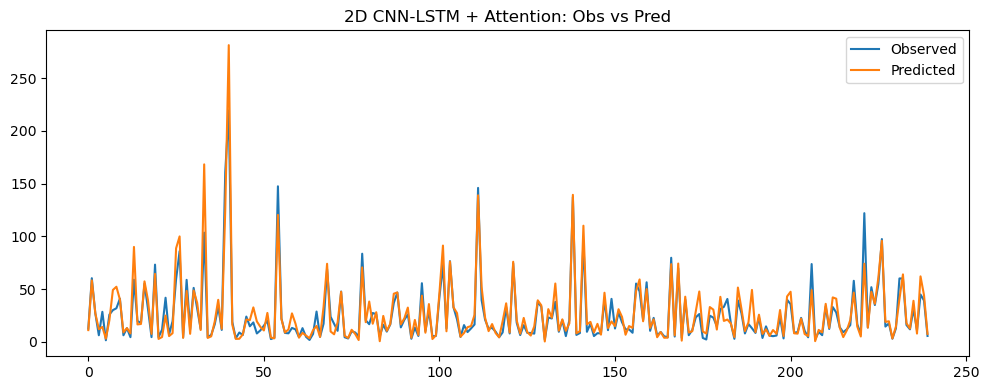

274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


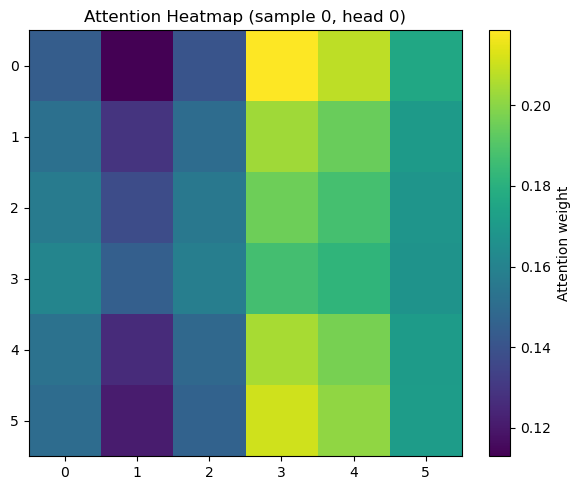

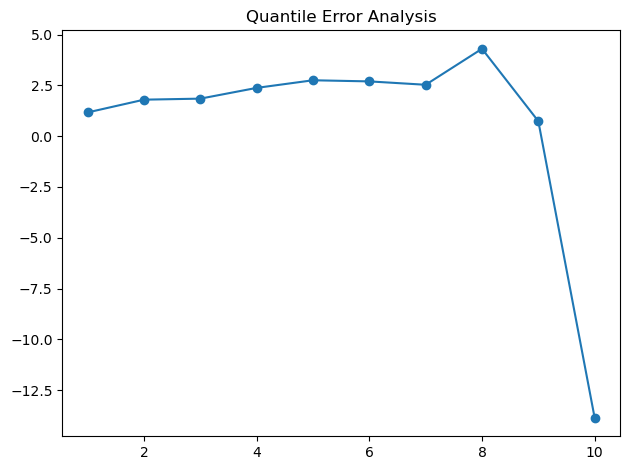

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
from keras.layers import (
    Input, TimeDistributed, Conv2D, MaxPooling2D,
    Flatten, LSTM, MultiHeadAttention, Dense)
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load & merge two stations
stations = ['eMalahleni','Middelburg']
dfs = []
for st in stations:
    df = pd.read_csv(
        f"C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/AirData/{st}IM.csv", sep=';', index_col=0)
    df.columns = [f"{st}_{c}" for c in df.columns]
    dfs.append(df)
data = pd.concat(dfs, axis=1).dropna()
values = data.values.astype('float32')

# 2) Frame as supervised
def series_to_supervised(data, n_in=1, n_out=1):
    df = pd.DataFrame(data)
    cols, names = [], []
    n_vars = df.shape[1]
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]
    for i in range(n_out):
        cols.append(df.shift(-i))
        suffix = '' if i==0 else f'+{i}'
        names += [f'var{j+1}(t{suffix})' for j in range(n_vars)]
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    agg.dropna(inplace=True)
    return agg

# 3) Normalize and frame with n_in=6
scaler   = MinMaxScaler((0,1))
scaled   = scaler.fit_transform(values)
n_in     = 6
n_vars   = scaled.shape[1]
reframed = series_to_supervised(scaled, n_in, 1)

# 4) Keep lag inputs + target (first var)
n_obs    = n_in * n_vars
df_trim  = reframed.iloc[:, list(range(n_obs)) + [n_obs]]
vals     = df_trim.values
X_all, Y = vals[:, :n_obs], vals[:, -1]

# 5) Reshape to (samples, timesteps, stations, features, 1)
n_stations = len(stations)
n_feats    = n_vars // n_stations
X = X_all.reshape((-1, n_in, n_stations, n_feats, 1))

# 6) Split
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val,   X_test,  Y_val,   Y_test  = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)

# 7) Build model: TimeDistributed 2D-CNN → LSTM → Attention → Dense
inp = Input(shape=(n_in, n_stations, n_feats, 1))

x = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'))(inp)
x = TimeDistributed(MaxPooling2D((1,2)))(x)
x = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'))(x)
x = TimeDistributed(MaxPooling2D((1,2)))(x)
x = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'))(x)
x = TimeDistributed(MaxPooling2D((1,2)))(x)

x = TimeDistributed(Flatten())(x)                # now shape = (batch, n_in, D)
x = LSTM(56, return_sequences=True)(x)           # shape = (batch, n_in, 56)
x = LSTM(56, return_sequences=True)(x) 
mha = MultiHeadAttention(num_heads=4, key_dim=56)
x = mha(query=x, value=x, key=x)                  # self-attention
x = Flatten()(x)

for _ in range(5):
    x = Dense(56, activation='relu')(x)
pred = Dense(1, activation='linear')(x)

model = Model(inputs=inp, outputs=pred)
model.compile(optimizer='adam', loss='mse')

# 8) Train
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=40, batch_size=32, verbose=1)

# 9) Plot training history
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training & Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

# 10) Predict & un-scale
pred_sc = model.predict(X_test)
y_pred  = pred_sc.flatten() * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]
y_true  = Y_test         * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

mae  = mean_absolute_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

plt.figure(figsize=(10,4))
plt.plot(y_true[:240], label='Observed')
plt.plot(y_pred[:240], label='Predicted')
plt.title('2D CNN-LSTM + Attention: Obs vs Pred')
plt.legend(); plt.tight_layout(); plt.show()

# 11) Attention heatmap for sample 0, head 0
# Build inference model for attention scores
inf_inp = Input(shape=(n_in, n_stations, n_feats, 1))
y = model.layers[1](inf_inp)  # TimeDistributed Conv2D
for layer in model.layers[2:7]:
    y = layer(y)
y = model.layers[7](y)        # TimeDistributed Flatten
y = model.layers[8](y)        # LSTM
y = model.layers[9](y)        # LSTM
_, scores = mha(query=y, value=y, key=y, return_attention_scores=True)
attn_model = Model(inputs=inf_inp, outputs=scores)

scores_np = attn_model.predict(X_test)
heatmap = scores_np[0, 0, :, :]  # sample 0, head 0

plt.figure(figsize=(6,5))
plt.imshow(heatmap, aspect='auto', cmap='viridis')
plt.colorbar(label='Attention weight')
plt.title('Attention Heatmap (sample 0, head 0)')
plt.tight_layout(); plt.show()

# 12) Quantile error analysis
errors = y_pred - y_true
quantiles, bins = pd.qcut(y_true, 10, duplicates='drop', retbins=True)
quantile_errors = [
    errors[(y_true >= bins[i]) & (y_true < bins[i+1])].mean()
    for i in range(len(bins)-1)
]
plt.figure()
plt.plot(range(1, len(quantile_errors)+1), quantile_errors, marker='o')
plt.title('Quantile Error Analysis')
plt.tight_layout(); plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 106s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 108s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 110s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 110s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 110s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 107s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 107s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 102s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 104s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 109s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 107s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
7375/7375 ━━━━━━━━━━━━━━━━━━━━ 107s 15

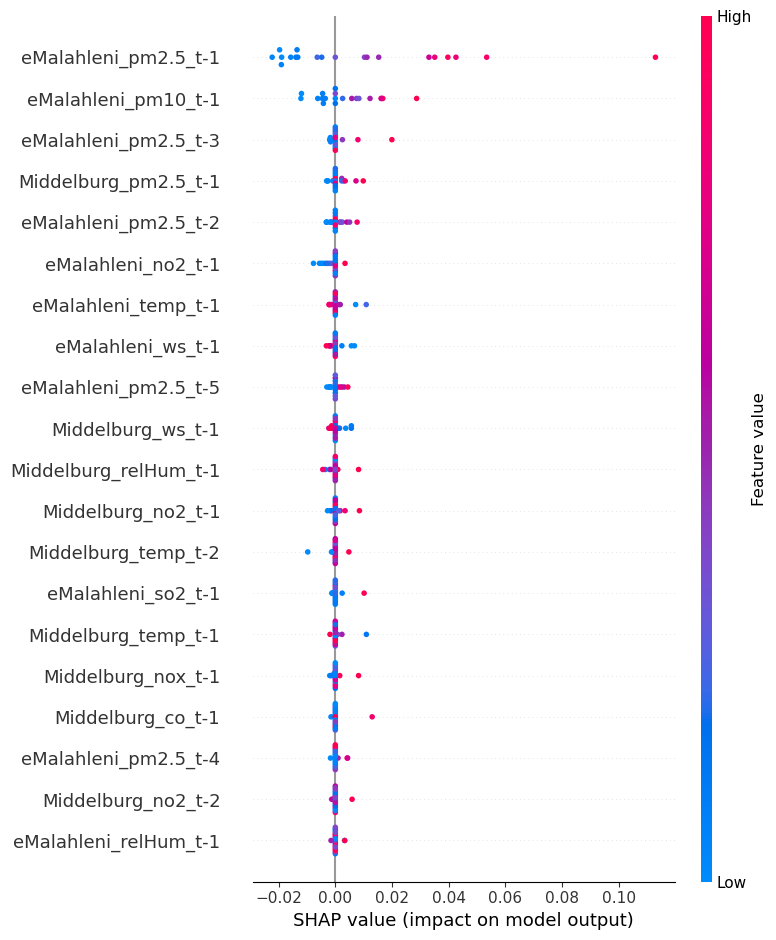

In [2]:
# 13) SHAP analysis (import after training)
import shap
bg_idx   = np.random.choice(len(X_train), 100, replace=False)
bg_flat  = X_train[bg_idx].reshape(100, -1)
ts_idx   = np.random.choice(len(X_test), 20, replace=False)
test_flat= X_test[ts_idx].reshape(20, -1)

f = lambda x: model.predict(x.reshape(-1, n_in, n_stations, n_feats, 1)).flatten()
explainer   = shap.KernelExplainer(f, bg_flat)
shap_values = explainer.shap_values(test_flat)

feat_names = [
    f"{col}_t-{lag}"
    for lag in range(n_in, 0, -1)
    for col in data.columns
]
shap.summary_plot(shap_values, test_flat, feature_names=feat_names)

# 14) Save model
model.save('2dcnn_lstm_attention_model.h5')